In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util  # For Cosine similarity
from bert_score import score  # For BERT score
from rouge_score import rouge_scorer  # For ROUGE
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction # For BLEU

/home/dferna3/.conda/envs/env_ft_llama2/lib/python3.8/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


## Metric Functions

In [2]:
cos_sim_model = SentenceTransformer("all-miniLM-L6-v2")

def cosine_similarity(text1, text2):
    text1_embedding = cos_sim_model.encode(text1, convert_to_tensor=True)
    text2_embedding = cos_sim_model.encode(text2, convert_to_tensor=True)
    return round(util.pytorch_cos_sim(text1_embedding, text2_embedding).item(), 2)

def bert_score(text1, text2):
    P, R, F1 = score([text1], [text2], lang="en", verbose=False)
    return round(F1[0].item(),2)

def rouge1_score(text1, text2):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    scores = scorer.score(text1, text2)
    return round(scores["rouge1"].fmeasure, 2)

def rouge2_score(text1, text2):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    scores = scorer.score(text1, text2)
    return round(scores["rouge2"].fmeasure, 2)

def rougeL_score(text1, text2):
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    scores = scorer.score(text1, text2)
    return round(scores["rougeL"].fmeasure, 2)

def bleu_score(text1, text2):
    # NLTK BLEU expects a list of reference tokens and a list of candidate tokens
    reference = text1.split()  # Tokenize reference
    candidate = text2.split()  # Tokenize candidate
    # Smoothing to avoid issues with short sentences
    smoothing = SmoothingFunction().method1
    return round(sentence_bleu([reference], candidate, smoothing_function=smoothing),4)

# List of metrics you want to use
comparison_functions = [
    ("Cosine Similarity", cosine_similarity),
    ("SBERT", bert_score),
    ("ROUGE_1", rouge1_score),
    ("ROUGE_2", rouge2_score),
    ("ROUGE_L", rougeL_score),
    ("BLEU", bleu_score)
]

/home/dferna3/.conda/envs/env_ft_llama2/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



=== Cosine Similarity ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.887821   
Gemini-1.5-flash-8b              0.887821             1.000000   
Gemini-2.0-flash-exp             0.870437             0.843172   
Gemini-1.5-pro                   0.867496             0.825547   
LlaMA-3.2-1B-Instruct            0.674680             0.655610   
LlaMA-3.2-3B-Instruct            0.495158             0.506519   
Qwen2.5-7B-Instruct-1M           0.406205             0.413264   
Qwen2.5-14B-Instruct-1M          0.406205             0.413264   
LlaMA-3.2-8B-Instruct            0.499844             0.493169   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.870437        0.867496   
Gemini-1.5-flash-8b                  0.843172        0.825547   
Gemini-2.0-flash-exp                 1.000000        0.927169   
Gemini-1.5-pro                       0.927169       

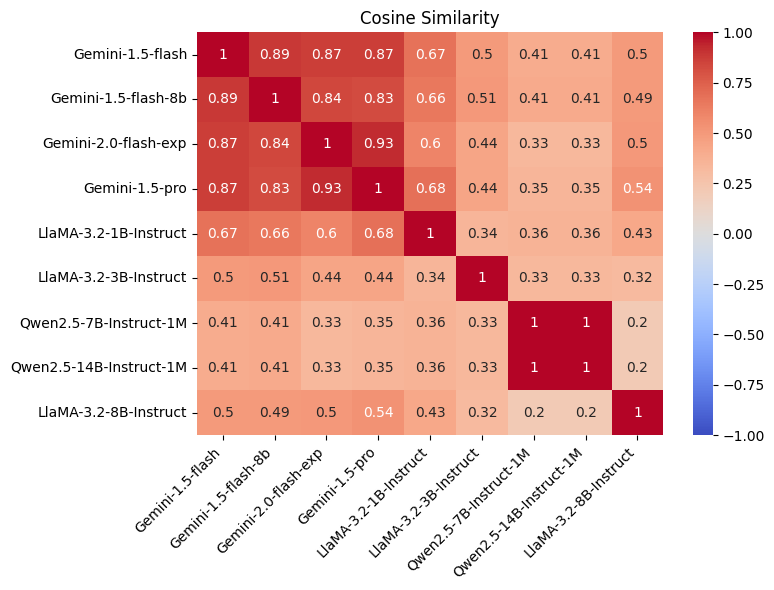

/home/dferna3/.conda/envs/env_ft_llama2/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference


=== SBERT ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.752842   
Gemini-1.5-flash-8b              0.752842             1.000000   
Gemini-2.0-flash-exp             0.493703             0.587954   
Gemini-1.5-pro                   0.647544             0.455389   
LlaMA-3.2-1B-Instruct            0.180739             0.224054   
LlaMA-3.2-3B-Instruct            0.109181             0.234481   
Qwen2.5-7B-Instruct-1M           0.585919             0.449712   
Qwen2.5-14B-Instruct-1M          0.338076             0.252744   
LlaMA-3.2-8B-Instruct            0.255322             0.165427   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.493703        0.647544   
Gemini-1.5-flash-8b                  0.587954        0.455389   
Gemini-2.0-flash-exp                 1.000000        0.663050   
Gemini-1.5-pro                       0.663050        1.000000   

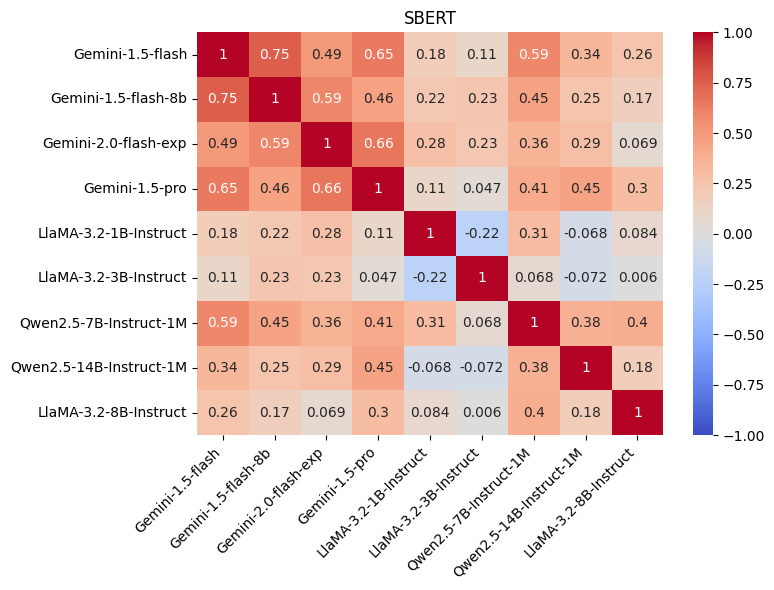


=== ROUGE_1 ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.780837   
Gemini-1.5-flash-8b              0.780837             1.000000   
Gemini-2.0-flash-exp             0.708621             0.697668   
Gemini-1.5-pro                   0.732512             0.641161   
LlaMA-3.2-1B-Instruct            0.633519             0.597955   
LlaMA-3.2-3B-Instruct            0.458183             0.414877   
Qwen2.5-7B-Instruct-1M           0.730894             0.635579   
Qwen2.5-14B-Instruct-1M          0.760255             0.638393   
LlaMA-3.2-8B-Instruct            0.664308             0.436470   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.708621        0.732512   
Gemini-1.5-flash-8b                  0.697668        0.641161   
Gemini-2.0-flash-exp                 1.000000        0.662785   
Gemini-1.5-pro                       0.662785        1.000000 

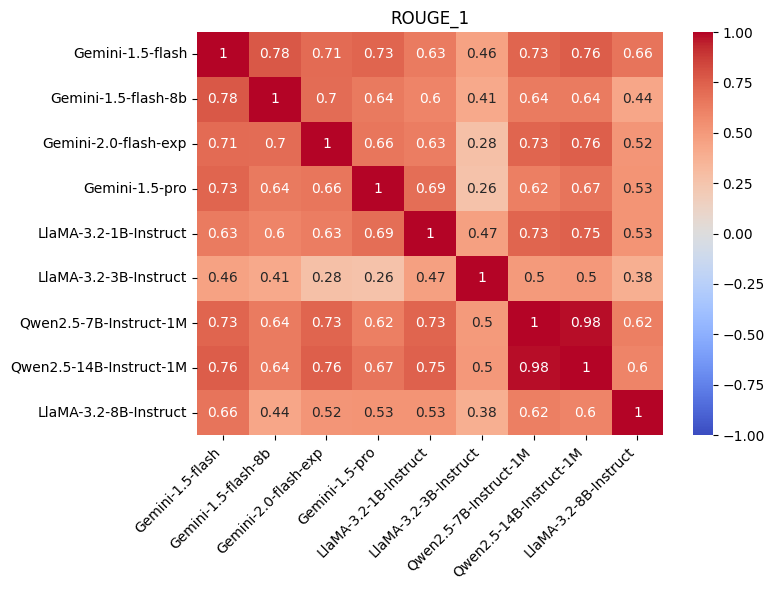


=== ROUGE_2 ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.733875   
Gemini-1.5-flash-8b              0.733875             1.000000   
Gemini-2.0-flash-exp             0.665983             0.658479   
Gemini-1.5-pro                   0.697617             0.594755   
LlaMA-3.2-1B-Instruct            0.504585             0.444378   
LlaMA-3.2-3B-Instruct            0.577911             0.520097   
Qwen2.5-7B-Instruct-1M           0.650428             0.523148   
Qwen2.5-14B-Instruct-1M          0.754700             0.592537   
LlaMA-3.2-8B-Instruct            0.634965             0.434885   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.665983        0.697617   
Gemini-1.5-flash-8b                  0.658479        0.594755   
Gemini-2.0-flash-exp                 1.000000        0.719944   
Gemini-1.5-pro                       0.719944        1.000000 

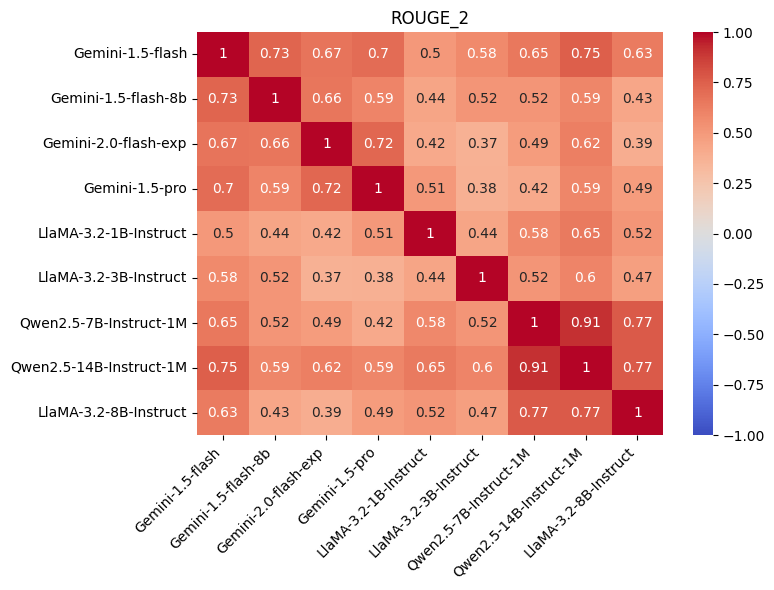


=== ROUGE_L ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.726794   
Gemini-1.5-flash-8b              0.726794             1.000000   
Gemini-2.0-flash-exp             0.415464             0.588544   
Gemini-1.5-pro                   0.450244             0.415789   
LlaMA-3.2-1B-Instruct            0.214065             0.268666   
LlaMA-3.2-3B-Instruct            0.004305             0.123304   
Qwen2.5-7B-Instruct-1M           0.450045             0.467405   
Qwen2.5-14B-Instruct-1M          0.461488             0.467056   
LlaMA-3.2-8B-Instruct            0.372140             0.314032   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.415464        0.450244   
Gemini-1.5-flash-8b                  0.588544        0.415789   
Gemini-2.0-flash-exp                 1.000000        0.449731   
Gemini-1.5-pro                       0.449731        1.000000 

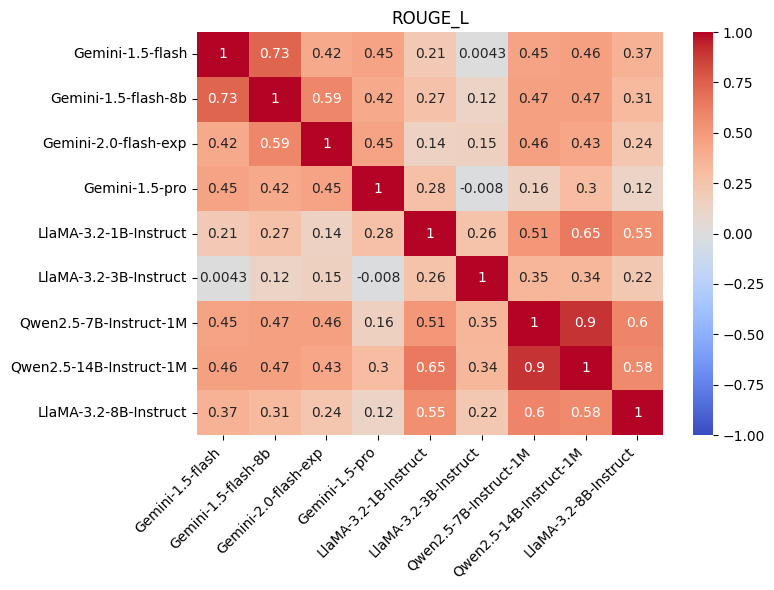


=== BLEU ===
                         Gemini-1.5-flash  Gemini-1.5-flash-8b  \
Gemini-1.5-flash                 1.000000             0.633831   
Gemini-1.5-flash-8b              0.633831             1.000000   
Gemini-2.0-flash-exp             0.678054             0.585499   
Gemini-1.5-pro                   0.694067             0.568781   
LlaMA-3.2-1B-Instruct            0.427003             0.155005   
LlaMA-3.2-3B-Instruct            0.561823             0.623690   
Qwen2.5-7B-Instruct-1M           0.474036             0.353607   
Qwen2.5-14B-Instruct-1M          0.651053             0.419933   
LlaMA-3.2-8B-Instruct            0.595317             0.283446   

                         Gemini-2.0-flash-exp  Gemini-1.5-pro  \
Gemini-1.5-flash                     0.678054        0.694067   
Gemini-1.5-flash-8b                  0.585499        0.568781   
Gemini-2.0-flash-exp                 1.000000        0.712342   
Gemini-1.5-pro                       0.712342        1.000000   


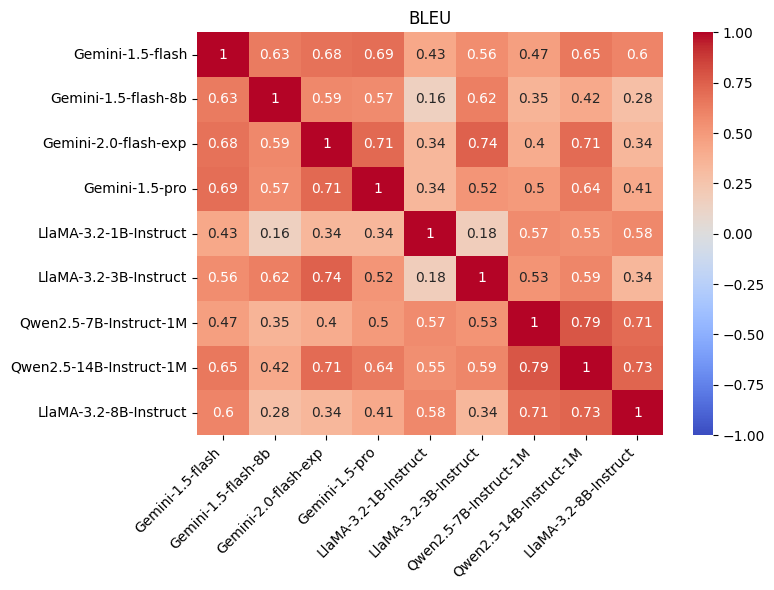

In [3]:
input_csv_path = '../data/results_final.csv'  # Replace with your actual path
df = pd.read_csv(input_csv_path, encoding = "ISO-8859-1")

# Identify the model columns (assuming they start from the 3rd column to the end)
# and the ground_truth is in the 2nd column.
ground_truth_col = 'ground_truth'

# Get all model columns by ignoring the first two columns (scenario_id, ground_truth)
model_columns = df.columns[2:]  # e.g. [model_1, model_2, ...]

# For each metric, we want to:
# 1. Calculate the score for each model’s output vs. ground_truth (row by row).
# 2. Create a DataFrame of the scores for all models.
# 3. Compute correlation among the model columns.
# 4. Plot the correlation matrix.

for metric_name, metric_fn in comparison_functions:
    # Create a new DataFrame that will hold the scores for each model under this metric
    score_df = pd.DataFrame()

    # For each model column, compute the metric vs. ground_truth
    for model_col in model_columns:
        scores = []
        for idx, row in df.iterrows():
            ref_text = str(row[ground_truth_col])    # Convert to str in case of any NaNs or numeric
            model_text = str(row[model_col])
            scores.append(metric_fn(ref_text, model_text))
        score_df[model_col] = scores

    # Now compute the correlation among the model columns
    corr_matrix = score_df.corr(method='pearson')  # or 'spearman'/'kendall' if you prefer

    print(f"\n=== {metric_name} ===")
    print(corr_matrix)

    ## Plot the heatmap
    #plt.figure(figsize=(8, 6))
    #sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    #plt.title(f"Correlation Matrix for {metric_name}")
    #plt.xticks(rotation=45)
    #plt.yticks(rotation=0)
    #plt.tight_layout()
    ## If you want to save the figure:
    ## plt.savefig(f"{metric_name}_correlation_matrix.png")
    #plt.show()

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                xticklabels=corr_matrix.columns, yticklabels=corr_matrix.index)
    plt.title(f"{metric_name}")
    plt.xticks(rotation=45, ha='right')  # Align labels properly
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save the heatmap as a PDF file
    plt.savefig(f"{metric_name}.pdf", format="pdf")

    # Show the plot
    plt.show()
